<a href="https://colab.research.google.com/github/SkSania/Alfido-task1-IRIS-dataset-/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Head ---
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
pet

<Figure size 1000x800 with 0 Axes>

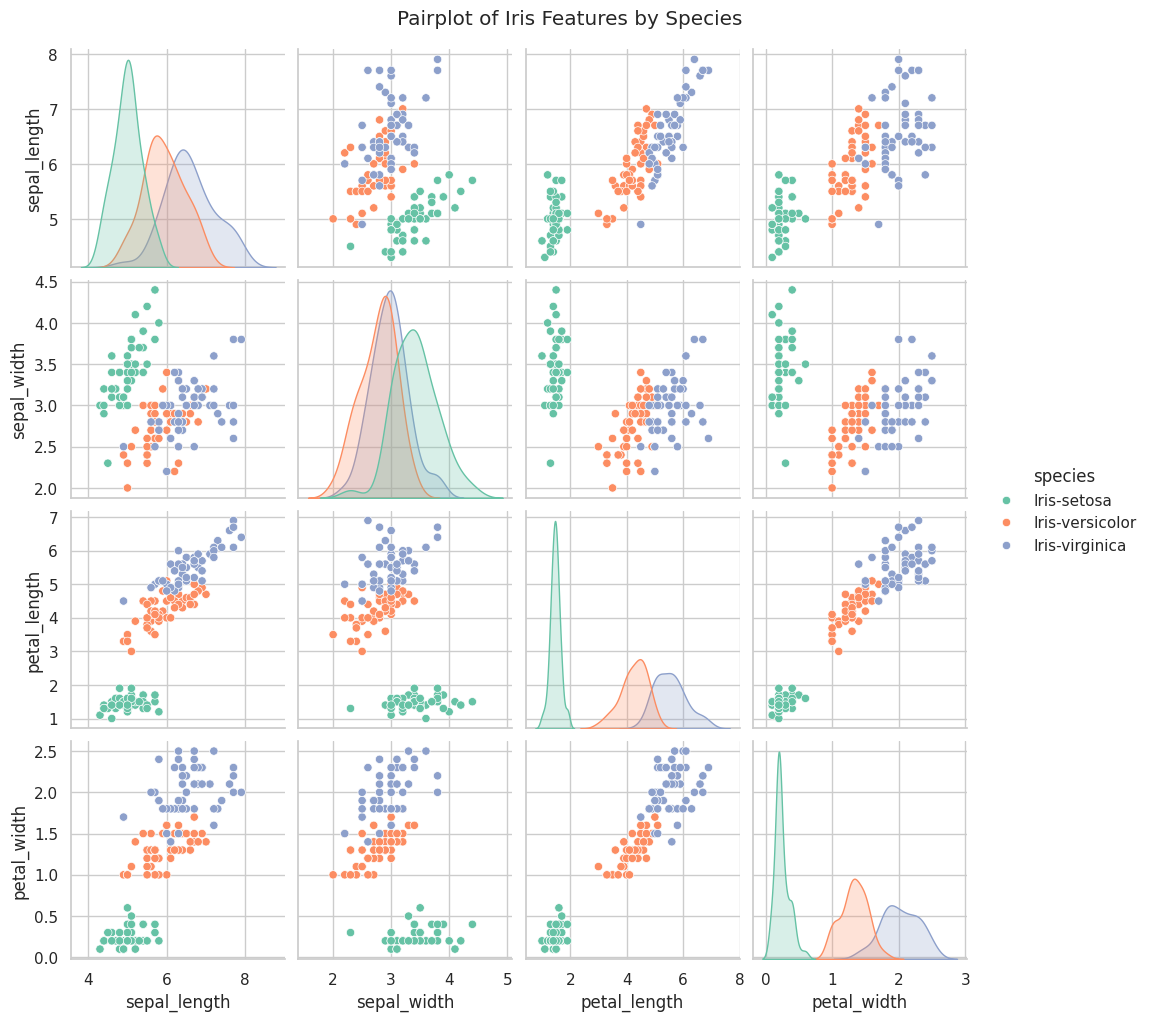

/tmp/ipykernel_7278/164236197.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')


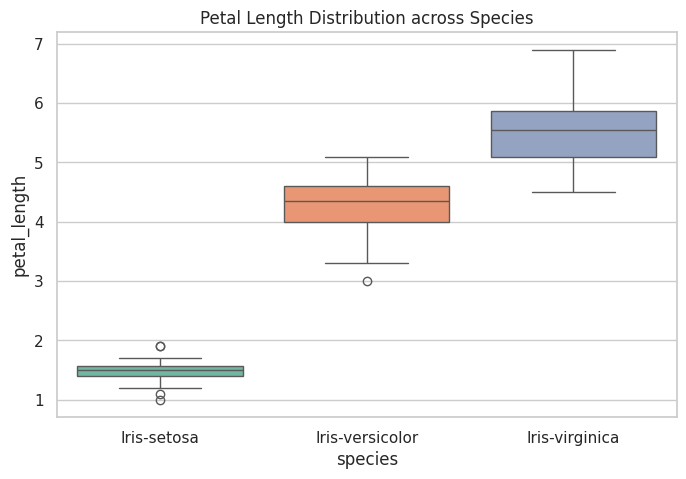


================ Logistic Regression ================
Accuracy: 0.9333
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


================ k-Nearest Neighbors ================
Accuracy: 0.9333
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


=====

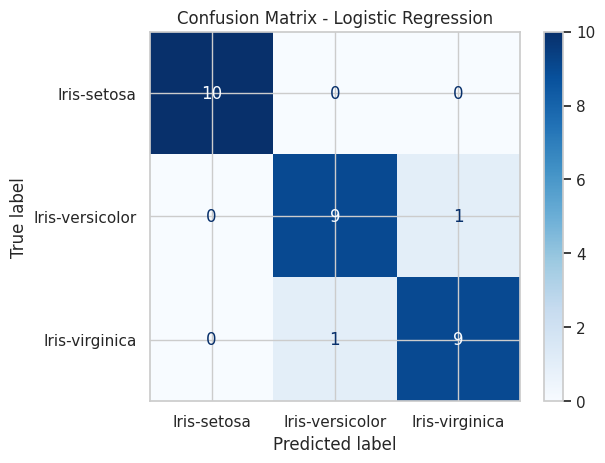


[INFO] Model and transformation artifacts saved as 'best_iris_model.joblib'

--- Running Sample Inference ---
Input features: [5.1, 3.5, 1.4, 0.2] -> Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# ==========================================
# 1. SETUP & LIBRARIES
# ==========================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set visual style
sns.set_theme(style="whitegrid")

# ==========================================
# 2. LOAD DATASET & BASIC EDA
# ==========================================
# Verify that the dataset file exists
csv_path = "IRIS[1].csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f" Please upload or download '{csv_path}' from the Kaggle dataset link to your environment.")

# Loading the specific Kaggle file
df = pd.read_csv(csv_path)

print("--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Statistical Summary ---")
print(df.describe())

# ==========================================
# 3. EDA VISUALIZATIONS (Class Separability)
# ==========================================
# Plot 1: Pairplot to show overall features separability
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.savefig("eda_pairplot.png", bbox_inches='tight')
plt.show()

# Plot 2: Boxplot for Petal Length distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')
plt.title("Petal Length Distribution across Species")
plt.savefig("eda_boxplot.png", bbox_inches='tight')
plt.show()

# ==========================================
# 4. DATA PREPROCESSING
# ==========================================
# Separate features and targeted labels
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_raw = df['species']

# Encode the string targets ('Iris-setosa', etc.) to numbers
le = LabelEncoder()
y = le.fit_transform(y_raw)
target_names = le.classes_

# Split dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (important for k-NN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. MODEL TRAINING & COMPARISON
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for LR and k-NN, raw data is sufficient for Decision Tree
    X_tr = X_train_scaled if name != "Decision Tree" else X_train
    X_te = X_test_scaled if name != "Decision Tree" else X_test

    # Train
    model.fit(X_tr, y_train)
    # Predict
    y_pred = model.predict(X_te)
    # Metric
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model_object": model,
        "accuracy": acc,
        "predictions": y_pred,
        "report": classification_report(y_test, y_pred, target_names=target_names)
    }

    print(f"\n================ {name} ================")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(results[name]["report"])

# ==========================================
# 6. EVALUATE BEST MODEL (Confusion Matrix)
# ==========================================
# Find model with highest accuracy
best_model_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"\nBest Model Selected: {best_model_name}")

best_pred = results[best_model_name]["predictions"]
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("best_model_confusion_matrix.png", bbox_inches='tight')
plt.show()

# ==========================================
# 7. SAVE THE BEST MODEL & SCALER ARTIFACTS
# ==========================================
model_artifacts = {
    "model": results[best_model_name]["model_object"],
    "scaler": scaler,
    "label_encoder": le,
    "model_name": best_model_name
}

joblib.dump(model_artifacts, "best_iris_model.joblib")
print("\n[INFO] Model and transformation artifacts saved as 'best_iris_model.joblib'")

# ==========================================
# 8. EXAMPLE INFERENCE CODE
# ==========================================
print("\n--- Running Sample Inference ---")

def predict_iris(sepal_len, sepal_wid, petal_len, petal_wid):
    # Load serialized artifacts
    artifacts = joblib.load("best_iris_model.joblib")
    loaded_model = artifacts["model"]
    loaded_scaler = artifacts["scaler"]
    loaded_le = artifacts["label_encoder"]
    name_of_model = artifacts["model_name"]

    # Format input array
    sample_data = np.array([[sepal_len, sepal_wid, petal_len, petal_wid]])

    # Apply scaling conditionally based on the chosen algorithm requirements
    if name_of_model != "Decision Tree":
        sample_data = loaded_scaler.transform(sample_data)

    # Predict and decode integer back to string label
    prediction_id = loaded_model.predict(sample_data)
    prediction_label = loaded_le.inverse_transform(prediction_id)
    return prediction_label[0]

# Test sample execution
sample_species = predict_iris(5.1, 3.5, 1.4, 0.2)
print(f"Input features: [5.1, 3.5, 1.4, 0.2] -> Predicted Species: {sample_species}")